# Embeddings

Para esta sección, se utilizarán algoritmos de reducción de dimensionalidad para la visualización de los datos de `CHOL` y `DPSM`.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings("ignore")

## Cargar datos

In [14]:
df_chol = pd.read_csv("../data/chol.csv")
df_dpsm = pd.read_csv("../data/dpsm.csv")

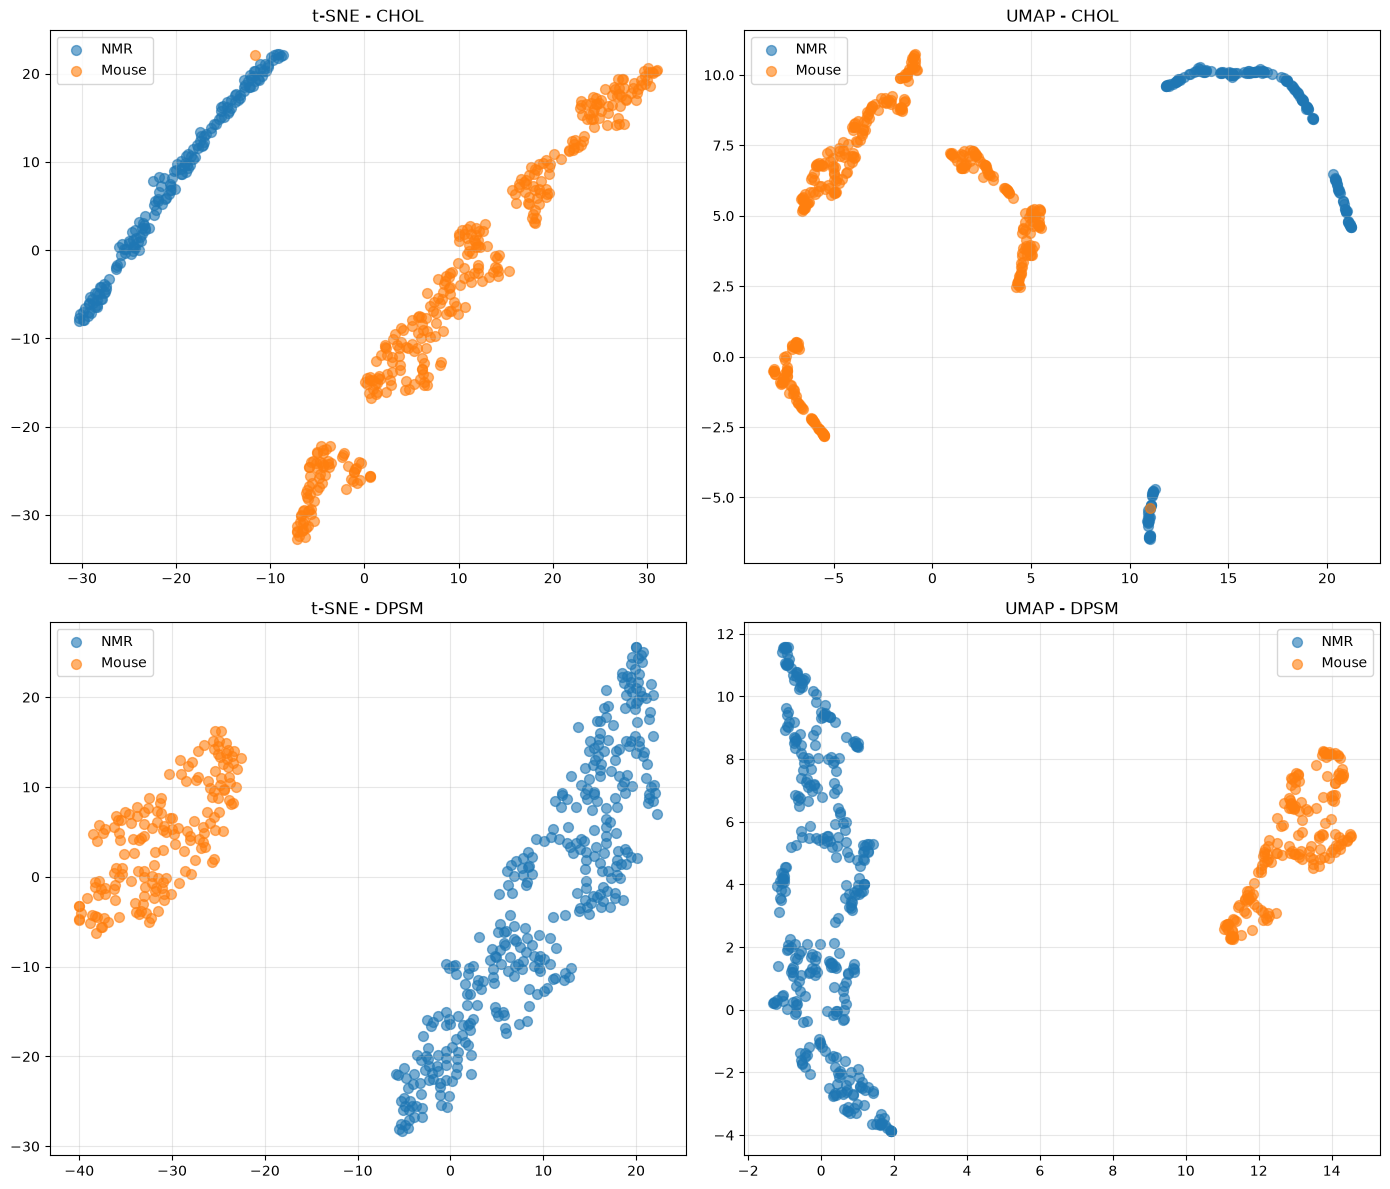

CPU times: user 31.6 s, sys: 1.38 s, total: 33 s
Wall time: 7.18 s


In [15]:
%%time
X_chol = df_chol.drop(columns=["target", "lipid_type", "resid"])
y_chol = df_chol["target"]
X_dpsm = df_dpsm.drop(columns=["target", "lipid_type", "resid"])
y_dpsm = df_dpsm["target"]

embedding_tsne_chol = TSNE(n_components=2, random_state=42).fit_transform(X_chol)
embedding_tsne_dpsm = TSNE(n_components=2, random_state=42).fit_transform(X_dpsm)
embedding_umap_chol = UMAP(n_components=2, random_state=42).fit_transform(X_chol)
embedding_umap_dpsm = UMAP(n_components=2, random_state=42).fit_transform(X_dpsm)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].scatter(embedding_tsne_chol[y_chol == 0, 0], embedding_tsne_chol[y_chol == 0, 1], label="NMR", alpha=0.6, s=50)
axes[0, 0].scatter(embedding_tsne_chol[y_chol == 1, 0], embedding_tsne_chol[y_chol == 1, 1], label="Mouse", alpha=0.6, s=50)
axes[0, 0].set_title("t-SNE - CHOL")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(embedding_umap_chol[y_chol == 0, 0], embedding_umap_chol[y_chol == 0, 1], label="NMR", alpha=0.6, s=50)
axes[0, 1].scatter(embedding_umap_chol[y_chol == 1, 0], embedding_umap_chol[y_chol == 1, 1], label="Mouse", alpha=0.6, s=50)
axes[0, 1].set_title("UMAP - CHOL")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(embedding_tsne_dpsm[y_dpsm == 0, 0], embedding_tsne_dpsm[y_dpsm == 0, 1], label="NMR", alpha=0.6, s=50)
axes[1, 0].scatter(embedding_tsne_dpsm[y_dpsm == 1, 0], embedding_tsne_dpsm[y_dpsm == 1, 1], label="Mouse", alpha=0.6, s=50)
axes[1, 0].set_title("t-SNE - DPSM")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(embedding_umap_dpsm[y_dpsm == 0, 0], embedding_umap_dpsm[y_dpsm == 0, 1], label="NMR", alpha=0.6, s=50)
axes[1, 1].scatter(embedding_umap_dpsm[y_dpsm == 1, 0], embedding_umap_dpsm[y_dpsm == 1, 1], label="Mouse", alpha=0.6, s=50)
axes[1, 1].set_title("UMAP - DPSM")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
print("=== CHOL ===")
print(f"t-SNE Silhouette: {silhouette_score(embedding_tsne_chol, y_chol):.3f}")
print(f"UMAP Silhouette: {silhouette_score(embedding_umap_chol, y_chol):.3f}")
print(f"t-SNE Davies-Bouldin: {davies_bouldin_score(embedding_tsne_chol, y_chol):.3f}")
print(f"UMAP Davies-Bouldin: {davies_bouldin_score(embedding_umap_chol, y_chol):.3f}")

print("\n=== DPSM ===")
print(f"t-SNE Silhouette: {silhouette_score(embedding_tsne_dpsm, y_dpsm):.3f}")
print(f"UMAP Silhouette: {silhouette_score(embedding_umap_dpsm, y_dpsm):.3f}")
print(f"t-SNE Davies-Bouldin: {davies_bouldin_score(embedding_tsne_dpsm, y_dpsm):.3f}")
print(f"UMAP Davies-Bouldin: {davies_bouldin_score(embedding_umap_dpsm, y_dpsm):.3f}")

=== CHOL ===
t-SNE Silhouette: 0.501
UMAP Silhouette: 0.598
t-SNE Davies-Bouldin: 0.808
UMAP Davies-Bouldin: 0.658

=== DPSM ===
t-SNE Silhouette: 0.631
UMAP Silhouette: 0.678
t-SNE Davies-Bouldin: 0.526
UMAP Davies-Bouldin: 0.454


`t-SNE` y `UMAP` presentan muy buenos resultados. `UMAP` es el que muestra mejores resultados (vs `t-SNE`) en los dos grupos de lípidos `CHOL` y `DPSM` con mayor cohesión (`silhouette_score`) y compacidad (`davies_bouldin_score`).